**Project 6. Customer Segmentation - Clustering**

**Dataset:** `Mall_Customers.csv`

**Kaggle link:** https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/data

**1. setup**

In [33]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [35]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = "Mall_Customers.csv"

**2. Load Dataset**

In [36]:
df = pd.read_csv(CSV_PATH)


In [37]:
df.shape

(200, 5)

In [38]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**3. Exploratory Data Analysis(EDA)**

In [39]:
# save CustomerID to a list for later use
customer_id = df["CustomerID"]

In [40]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [42]:
# drop customer id as it is not useful for clustering
df.drop("CustomerID", axis=1, inplace=True)

In [43]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [44]:
# check missing values
df.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [45]:
# checck encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(10)) #find top 10 repeating values in each column

Gender
Female    112
Male       88
Name: count, dtype: int64
Age
32    11
35     9
31     8
19     8
30     7
49     7
23     6
40     6
36     6
27     6
Name: count, dtype: int64
Annual Income (k$)
54    12
78    12
60     6
48     6
63     6
71     6
62     6
87     6
40     4
43     4
Name: count, dtype: int64
Spending Score (1-100)
42    8
55    7
73    6
46    6
48    5
52    5
50    5
59    5
75    5
35    5
Name: count, dtype: int64


In [46]:
# check for duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print(f"Number of duplicate rows: {num_duplicates}")

# code to drop duplicates if any
# df.drop_duplicates(inplace=True)

Number of duplicate rows: 0


*Data Visualization*

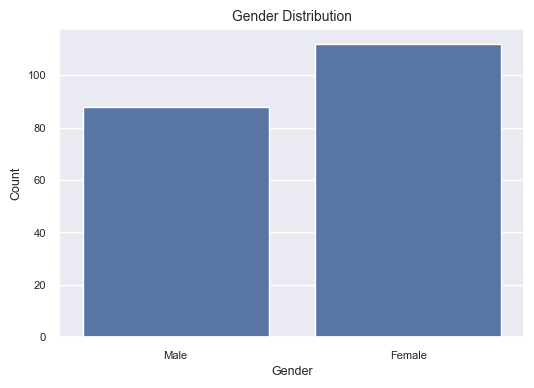

In [47]:
#Gender Distibution
plt.figure(figsize=(6, 4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")     
plt.show()

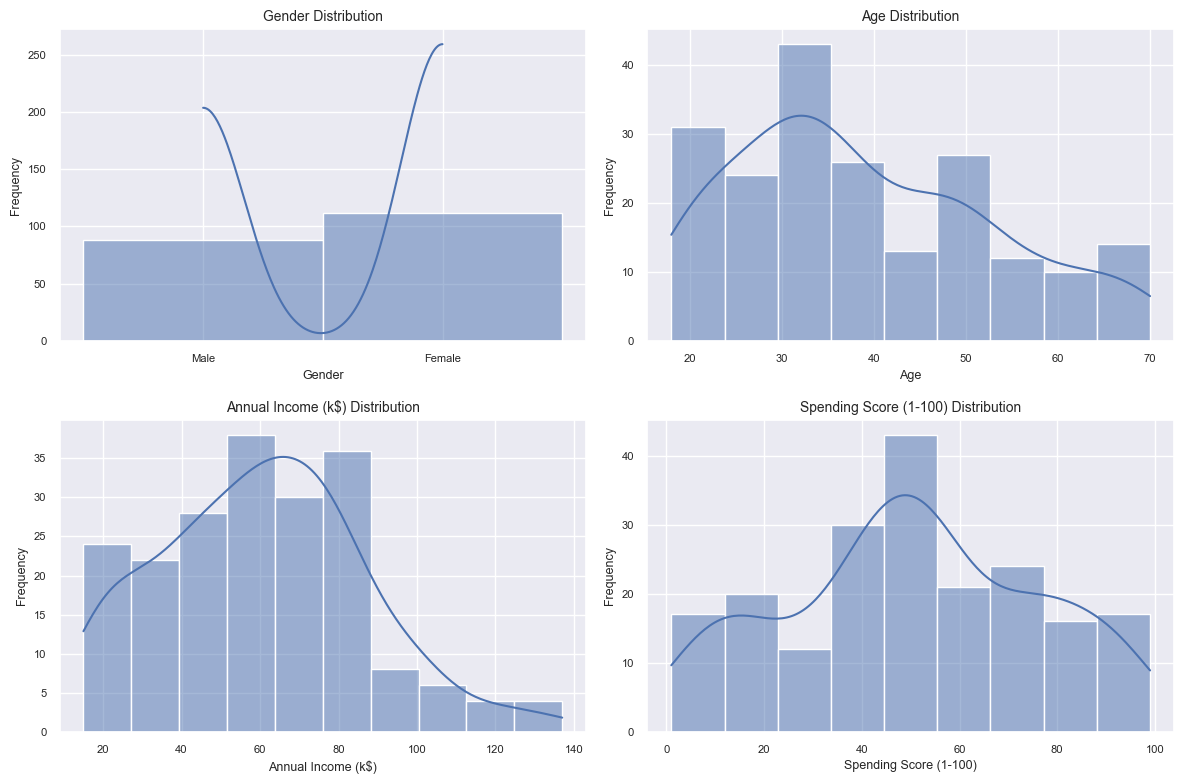

In [48]:
# histogram plot - distibution
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
plt.tight_layout()
plt.show()
                         

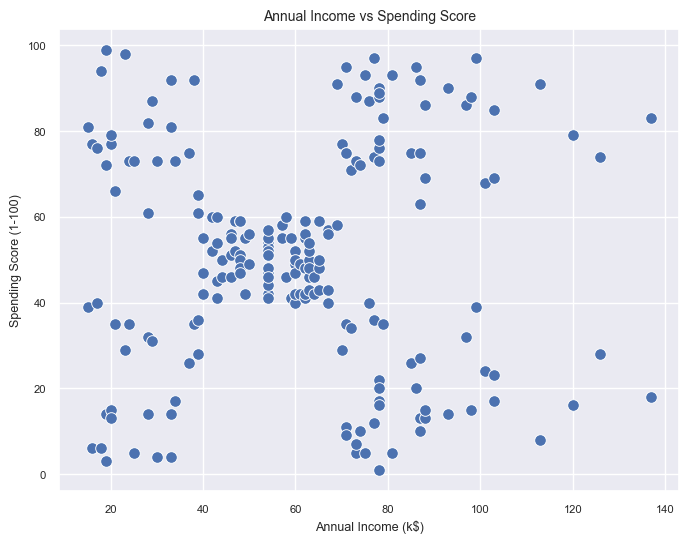

In [49]:
# scatter plot - relationship between annual income and spending score
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)", s=70, data=df)
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

**We can clearly see clusters in the plot**

**4. Data preprocessing**

In [50]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [51]:
# feature selection
columns_to_select = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[columns_to_select]

In [52]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [53]:
# scale the features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [54]:
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

**5. Elbow mehtod - WCSS
(Find best K value)**

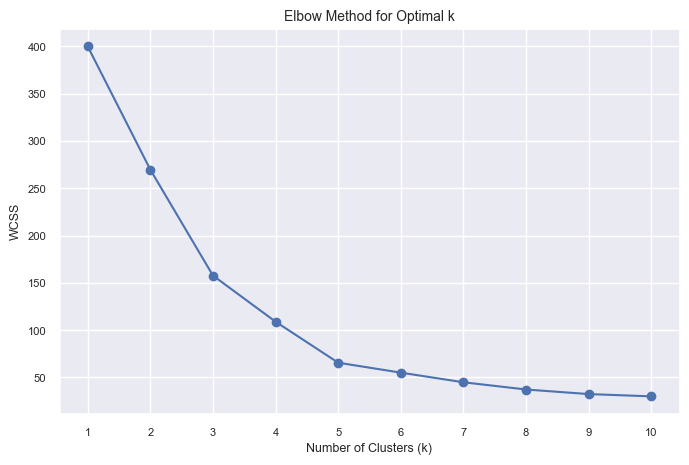

In [55]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker="o")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.xticks(k_range)
plt.show()

**Key observations:**
- Very steep drop from K = 1 → 2 → 3
- Still a noticeable improvement till K = 4
- After K = 5, the curve starts flattening
- From K = 6 onward, the reduction in WCSS is marginal

📌 This clear change in slope around K = 5 is the elbow point.

**6. K-Means Clustering**

In [56]:
K_FINAL = 5

In [57]:
kmeans_final = KMeans(
    n_clusters=K_FINAL,
    random_state=RANDOM_STATE,
    n_init=10
)

In [58]:
kmeans_final.fit(X_scaled)

,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [59]:
clusters = kmeans_final.predict(X_scaled)

In [60]:
clusters

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [61]:
kmeans_final.fit(X_scaled)

,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [62]:
# copy of original df
df_clusters = df.copy(deep=True)

In [63]:
df_clusters

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [64]:
df_clusters["Cluster"] = clusters

In [65]:
df_clusters.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4


In [67]:
df_clusters["CustomerID"] = customer_id

In [68]:
df_clusters.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,CustomerID
0,Male,19,15,39,4,1
1,Male,21,15,81,2,2
2,Female,20,16,6,4,3
3,Female,23,16,77,2,4
4,Female,31,17,40,4,5


**7. Evaluation**

In [69]:
k_means_score = silhouette_score(X_scaled, df_clusters["Cluster"])
print(f"Silhouette Score for K-Means Clustering: {k_means_score:.4f}")

Silhouette Score for K-Means Clustering: 0.5547


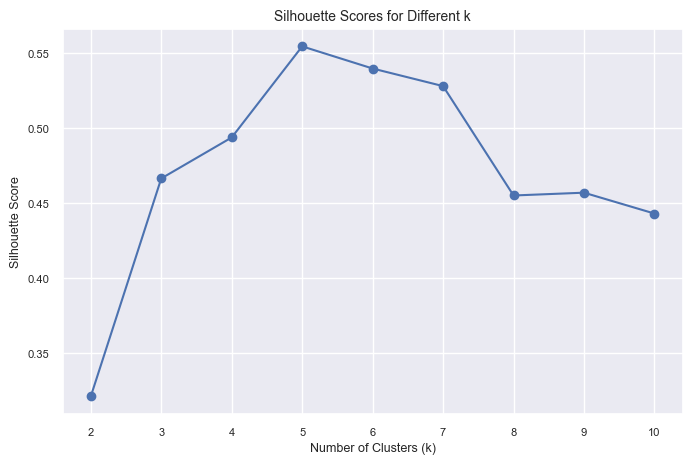

In [72]:
sil_scores =[]

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, cluster_labels)
    sil_scores.append(sil)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores, marker="o")
plt.title("Silhouette Scores for Different k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.show()

**8. Visualize Clusters**

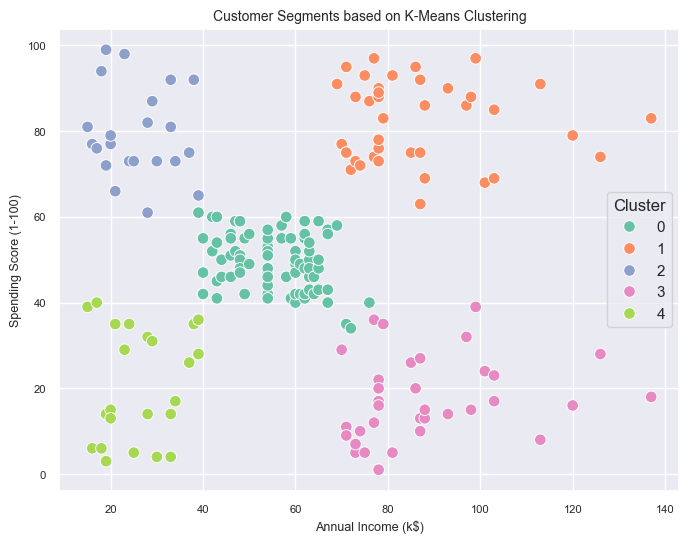

In [73]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2",
    data=df_clusters,
    s=70
)
plt.title("Customer Segments based on K-Means Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster") 
plt.show()

**9. Cluster Interpretation (Business Profiling)**

In [74]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [77]:
profile_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

cluster_sizes = df_clusters["Cluster"].value_counts().sort_index()
cluster_profile_mean = df_clusters.groupby("Cluster")[profile_cols].mean()
cluster_profile_median = df_clusters.groupby("Cluster")[profile_cols].median()

print("Cluster Sizes:\n")
print(cluster_sizes)

print("Cluster Profile (Mean):\n")
display(cluster_profile_mean)

print("Cluster Profile (Median):\n")
display(cluster_profile_median)

Cluster Sizes:

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64
Cluster Profile (Mean):



,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


Cluster Profile (Median):



,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.00,54.00,50.00
1,32.00,79.00,83.00
2,23.50,24.50,77.00
3,42.00,85.00,16.00
4,46.00,25.00,17.00


**10. Segment Function (for new customer)**

In [78]:
def assign_customer_segment(income_k, spending_score, scaler, model):
    new_point = pd.DataFrame(
        [[income_k, spending_score]],
        columns=["Annual Income (k$)", "Spending Score (1-100)"]
    )
    
    new_point_scaled = scaler.transform(new_point)
    cluster_id = model.predict(new_point_scaled)[0]
    return cluster_id

In [79]:
# Example usage
new_cluster = assign_customer_segment(
    income_k=60,
    spending_score=65,
    scaler=scaler,
    model=kmeans_final
)

print("\n✅ New customer assigned to cluster:", new_cluster)


✅ New customer assigned to cluster: 0
